# NLP Assignment 2 - Layer Reduction with Similar Perplexity

**Hypothesis:** Several Transformer layers are redundant. We can remove or
replace them - using hard removal, layer averaging, an affine/linear merge
(Assignment 1 method), or a ternary low-rank **TerGRASP** bridge - while
keeping perplexity (PPL) approximately the same.

**Options tested (per model):**

1. **Hard layer removal** (ShortGPT-style): delete layers with the smallest
   block influence, measured by angular distance `1 - cos(h_in, h_out)`.
2. **Weighted adjacent-layer averaging:** merge two neighbouring blocks by
   averaging corresponding parameters.
3. **Affine/linear merge (Assignment 1):** fit affine maps for two adjacent
   blocks on hidden states, then compose them into one block.
4. **TerGRASP hybrid replacement:** replace redundant blocks with a
   1.58-bit ternary low-rank bridge module.
5. **Random-removal control:** remove the same number of *random* layers to
   verify that angular-distance selection is what makes removal cheap.

**Models:** GPT-3 weights are not publicly released, so we use two small,
open Hugging Face stand-ins:

- `openai-community/gpt2` (124M, 12 layers) - the Assignment 1 model
- `HuggingFaceTB/SmolLM-135M` (135M, 30 layers)


In [1]:
!pip install -q transformers datasets accelerate pandas psutil matplotlib

import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


zsh:1: command not found: pip


/Users/sumitjha/Downloads/nlp-layer-reduction/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.14.1
Transformers: 5.18.0
device: cpu


In [2]:
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_IDS = [
    "openai-community/gpt2",
    "HuggingFaceTB/SmolLM-135M",
]

tokenizers = {}
for mid in MODEL_IDS:
    tok = AutoTokenizer.from_pretrained(mid)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    tokenizers[mid] = tok
    print(mid, "| pad token set:", tok.pad_token is not None)


openai-community/gpt2 | pad token set: True


HuggingFaceTB/SmolLM-135M | pad token set: True


In [4]:
from datasets import load_dataset

dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1"
)

print(dataset)


DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


In [5]:
def join_nonempty(split):
    return "\n\n".join(
        x for x in split["text"]
        if x is not None and x.strip()
    )

train_text = join_nonempty(dataset["train"])
validation_text = join_nonempty(dataset["validation"])
test_text = join_nonempty(dataset["test"])

print({k: len(v) for k, v in
       [("train", train_text), ("validation", validation_text),
        ("test", test_text)]})


{'train': 10940522, 'validation': 1147070, 'test': 1291402}


In [6]:
# Model-architecture helpers: GPT-2 stores blocks in model.transformer.h,
# Llama-style models (SmolLM) store them in model.model.layers.

def get_layers(model):
    if hasattr(model, "transformer") and hasattr(model.transformer, "h"):
        return model.transformer.h
    return model.model.layers


def set_layers(model, blocks):
    blocks = torch.nn.ModuleList(blocks)
    if hasattr(model, "transformer") and hasattr(model.transformer, "h"):
        model.transformer.h = blocks
        model.config.n_layer = len(blocks)
    else:
        model.model.layers = blocks
        model.config.num_hidden_layers = len(blocks)
    if hasattr(model.config, "layer_types") and model.config.layer_types is not None:
        model.config.layer_types = model.config.layer_types[: len(blocks)]
    return model


def load_fresh_model(model_id):
    model = AutoModelForCausalLM.from_pretrained(model_id)
    model.config.use_cache = False
    model.eval()
    return model


def hidden_size(model):
    cfg = model.config
    return getattr(cfg, "n_embd", None) or cfg.hidden_size


In [7]:
import math

EVAL_BLOCK_SIZE = 256
EVAL_TOKENS = 5000

def calculate_ppl(model, text, model_id, block_size=EVAL_BLOCK_SIZE,
                  max_tokens=EVAL_TOKENS):
    """Same non-overlapping-chunk PPL approximation as Assignment 1."""
    model.eval()
    tok = tokenizers[model_id]
    ids = tok(
        text,
        return_tensors="pt",
        add_special_tokens=False
    )["input_ids"][0]

    if max_tokens is not None:
        ids = ids[:max_tokens]

    n_blocks = len(ids) // block_size
    if n_blocks == 0:
        raise ValueError("Not enough tokens for one evaluation block.")

    total_nll = 0.0
    total_tokens = 0

    with torch.no_grad():
        for i in range(n_blocks):
            x = ids[i * block_size:(i + 1) * block_size].unsqueeze(0).to(device)
            outputs = model(input_ids=x, labels=x, use_cache=False)
            count = x.numel() - 1
            total_nll += outputs.loss.item() * count
            total_tokens += count

    return math.exp(total_nll / total_tokens)


In [8]:
import time

def parameter_count(model):
    return sum(p.numel() for p in model.parameters())


def measure_latency(model, text, model_id, seq_len=256, repeat=10):
    model.eval()
    tok = tokenizers[model_id]
    ids = tok(
        text, return_tensors="pt", add_special_tokens=False
    )["input_ids"][:, :seq_len].to(device)

    with torch.no_grad():
        for _ in range(3):
            _ = model(ids, use_cache=False)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(repeat):
            _ = model(ids, use_cache=False)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t1 = time.perf_counter()
    return 1000.0 * (t1 - t0) / repeat


In [9]:
import gc

def free_model(model):
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [10]:
# Baseline PPL, parameters and latency for both models
import pandas as pd

rows = []
for mid in MODEL_IDS:
    m = load_fresh_model(mid).to(device)
    ppl = calculate_ppl(m, validation_text, mid)
    params = parameter_count(m)
    lat = measure_latency(m, validation_text, mid)
    rows.append({"model": mid, "layers": len(get_layers(m)),
                 "ppl": ppl, "params": params, "latency_ms": lat})
    print(f"{mid}: PPL={ppl:.2f} params={params:,} latency={lat:.2f} ms")
    free_model(m)

baseline_df = pd.DataFrame(rows)
baseline_df


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 22693.46it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (249749 > 1024). Running this sequence through the model will result in indexing errors


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


openai-community/gpt2: PPL=40.36 params=124,439,808 latency=63.94 ms


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 11201.72it/s]

HuggingFaceTB/SmolLM-135M: PPL=19.66 params=134,515,008 latency=680.64 ms


,model,layers,ppl,params,latency_ms
0,openai-community/gpt2,12,40.358158,124439808,63.944383
1,HuggingFaceTB/SmolLM-135M,30,19.655733,134515008,680.635875


In [11]:
# Assignment-1 style linear sanity check: merging *linear* blocks by
# composing their weight matrices is exact.
torch.manual_seed(SEED)
d, n = 16, 128
X = torch.randn(n, d)
W1 = torch.randn(d, d)
W2 = torch.randn(d, d)
sequential = (X @ W1) @ W2
composed = X @ (W1 @ W2)
print("max_abs_error:", (sequential - composed).abs().max().item())
print("mse:", torch.mean((sequential - composed) ** 2).item())


max_abs_error: 1.1444091796875e-05
mse: 4.913057807809373e-12


In [12]:
import torch.nn.functional as F

CALIB_N_CHARS = 2000

def block_influence(model, model_id, text, n_chars=CALIB_N_CHARS):
    """Angular distance BI_l = 1 - cos(h_in, h_out) per decoder layer.

    Small BI => the layer is close to identity => safe to remove/replace.
    """
    model.eval()
    tok = tokenizers[model_id]
    ids = tok(
        text[:n_chars], return_tensors="pt", add_special_tokens=False
    ).to(device)

    with torch.no_grad():
        out = model(**ids, output_hidden_states=True, use_cache=False)

    hs = out.hidden_states  # tuple of len n_layers + 1
    bis = []
    for i in range(len(hs) - 1):
        cos = F.cosine_similarity(hs[i].float(), hs[i + 1].float(), dim=-1).mean().item()
        bis.append(1.0 - cos)
    return bis


for mid in MODEL_IDS:
    m = load_fresh_model(mid).to(device)
    bis = block_influence(m, mid, train_text)
    order = sorted(range(len(bis)), key=lambda i: bis[i])
    print(f"\n{mid} - top-5 most redundant layers (smallest angular distance):")
    for i in order[:5]:
        print(f"  layer {i:2d}: BI = {bis[i]:.5f}")
    free_model(m)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 14231.02it/s]


openai-community/gpt2 - top-5 most redundant layers (smallest angular distance):
  layer  4: BI = 0.02960
  layer  1: BI = 0.02980
  layer  2: BI = 0.03193
  layer  3: BI = 0.03261
  layer  5: BI = 0.03447


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 11310.78it/s]


HuggingFaceTB/SmolLM-135M - top-5 most redundant layers (smallest angular distance):
  layer  2: BI = 0.01676
  layer 27: BI = 0.01753
  layer  5: BI = 0.01828
  layer  4: BI = 0.01846
  layer  3: BI = 0.01880


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 14837.16it/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 13182.78it/s]

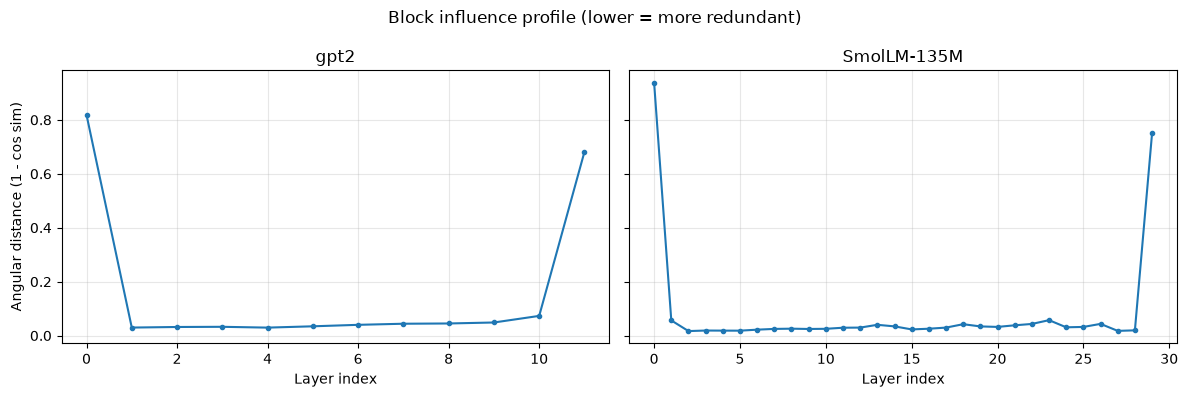

In [13]:
import matplotlib.pyplot as plt

profiles = {}
for mid in MODEL_IDS:
    m = load_fresh_model(mid).to(device)
    profiles[mid] = block_influence(m, mid, train_text)
    free_model(m)

fig, axes = plt.subplots(1, len(MODEL_IDS), figsize=(12, 4), sharey=True)
for ax, mid in zip(axes, MODEL_IDS):
    ax.plot(range(len(profiles[mid])), profiles[mid], marker="o", ms=3)
    ax.set_title(mid.split("/")[-1])
    ax.set_xlabel("Layer index")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Angular distance (1 - cos sim)")
plt.suptitle("Block influence profile (lower = more redundant)")
plt.tight_layout()
plt.show()


## Option 1 - Hard layer removal (ShortGPT-style)

Remove the `k` layers with the **smallest** block influence, then measure PPL.


In [14]:
def hard_remove(model_id, indices):
    model = load_fresh_model(model_id)
    blocks = list(get_layers(model))
    kept = [b for i, b in enumerate(blocks) if i not in set(indices)]
    set_layers(model, kept)
    for i, layer in enumerate(get_layers(model)):
        if hasattr(layer, "layer_idx"):
            layer.layer_idx = i
        if hasattr(layer, "self_attn") and hasattr(layer.self_attn, "layer_idx"):
            layer.self_attn.layer_idx = i
    return model


hard_rows = []
K_LIST = [1, 2, 3, 4]

for mid in MODEL_IDS:
    m0 = load_fresh_model(mid).to(device)
    bis = block_influence(m0, mid, train_text)
    free_model(m0)
    order = sorted(range(len(bis)), key=lambda i: bis[i])

    for k in K_LIST:
        target = sorted(order[:k])
        m = hard_remove(mid, target).to(device)
        ppl = calculate_ppl(m, validation_text, mid)
        hard_rows.append({"model": mid, "k": k, "removed": target, "ppl": ppl})
        print(f"{mid} | hard-remove k={k} {target}: PPL={ppl:.2f}")
        free_model(m)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 14541.04it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 12262.84it/s]

openai-community/gpt2 | hard-remove k=1 [4]: PPL=48.62


...

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 11516.18it/s]

HuggingFaceTB/SmolLM-135M | hard-remove k=3 [2, 5, 27]: PPL=35.68


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 11081.17it/s]

HuggingFaceTB/SmolLM-135M | hard-remove k=4 [2, 4, 5, 27]: PPL=45.71


## Option 5 (control) - Random layer removal

Same `k`, but layers are chosen at random (seed fixed). If the angular-distance
ranking matters, random removal should hurt PPL much more.


In [15]:
random_rows = []

for mid in MODEL_IDS:
    m0 = load_fresh_model(mid).to(device)
    n_layers = len(get_layers(m0))
    free_model(m0)

    for k in [1, 2, 3]:
        rng = random.Random(0)
        target = sorted(rng.sample(range(n_layers), k))
        m = hard_remove(mid, target).to(device)
        ppl = calculate_ppl(m, validation_text, mid)
        random_rows.append({"model": mid, "k": k, "removed": target, "ppl": ppl})
        print(f"{mid} | random-remove k={k} {target}: PPL={ppl:.2f}")
        free_model(m)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 12690.52it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 11753.42it/s]

openai-community/gpt2 | random-remove k=1 [6]: PPL=47.06


...

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 10348.23it/s]

HuggingFaceTB/SmolLM-135M | random-remove k=2 [12, 27]: PPL=31.84


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 11788.57it/s]

HuggingFaceTB/SmolLM-135M | random-remove k=3 [12, 24, 27]: PPL=40.78


## Option 2 - Weighted adjacent-layer averaging

Merge the redundant layer `L` into its neighbour `L+1` by averaging
corresponding parameters: `theta = 0.5 * theta_L + 0.5 * theta_(L+1)`.


In [16]:
import copy

def avg_merge(model_id, merge_pairs, alpha=0.5):
    """merge_pairs: list of (L, L+1) original block indices, most redundant first."""
    model = load_fresh_model(model_id)
    blocks = list(get_layers(model))
    orig = {i: blocks[i] for i in range(len(blocks))}

    to_remove = set()
    new_blocks = []
    for idx, b in enumerate(blocks):
        if idx in to_remove:
            continue
        new_blocks.append(b)

    for (i, j) in merge_pairs:
        # find current positions by object identity
        pos_j = next(p for p, b in enumerate(new_blocks) if b is orig[j])
        merged = copy.deepcopy(orig[j])
        p1 = dict(orig[i].named_parameters())
        p2 = dict(orig[j].named_parameters())
        with torch.no_grad():
            for name, p in merged.named_parameters():
                p.copy_(alpha * p1[name] + (1.0 - alpha) * p2[name])
        to_remove.add(i)
        new_blocks[pos_j] = merged
        # remove block i if still present
        new_blocks = [b for p_idx, b in enumerate(new_blocks)
                      if not (b is orig[i])]

    return set_layers(model, new_blocks)


avg_rows = []

for mid in MODEL_IDS:
    m0 = load_fresh_model(mid).to(device)
    bis = block_influence(m0, mid, train_text)
    free_model(m0)
    order = sorted(range(len(bis)), key=lambda i: bis[i])
    n_layers = len(bis)

    for k in [1, 2, 3]:
        cand = [i for i in order if i + 1 < n_layers][:k]
        pairs = [(i, i + 1) for i in sorted(set(cand))]
        try:
            m = avg_merge(mid, pairs).to(device)
            ppl = calculate_ppl(m, validation_text, mid)
            avg_rows.append({"model": mid, "k": k, "pairs": pairs, "ppl": ppl})
            print(f"{mid} | avg-merge k={k} {pairs}: PPL={ppl:.2f}")
            free_model(m)
        except Exception as e:
            print(f"{mid} | avg-merge k={k} failed: {e}")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 12866.50it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 12487.57it/s]

openai-community/gpt2 | avg-merge k=1 [(4, 5)]: PPL=246.51


...

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 10712.82it/s]

HuggingFaceTB/SmolLM-135M | avg-merge k=2 [(2, 3), (27, 28)]: PPL=47.89


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 10503.62it/s]

HuggingFaceTB/SmolLM-135M | avg-merge k=3 [(2, 3), (5, 6), (27, 28)]: PPL=86.08


## Option 3 - Affine/linear merge (Assignment 1 method)

For a pair `(L, L+1)` collect hidden states `X -> Y1 -> Y2`, fit affine maps

`Y1 = A1 X + b1`, `Y2 = A2 Y1 + b2`

and replace both layers with one block:

`Y2 = (A2 @ A1) X + (A2 @ b1 + b2)`


In [17]:
def collect_pair_states(model, model_id, L, text, n_chars=4000):
    tok = tokenizers[model_id]
    ids = tok(text[:n_chars], return_tensors="pt",
              add_special_tokens=False).to(device)
    Xs, Y1s, Y2s = [], [], []
    blocks = get_layers(model)

    def hook_in(module, args):
        Xs.append(args[0].detach().float().reshape(-1, args[0].shape[-1]).cpu())

    h1, h2 = [], []

    def hook_out1(module, args, output):
        o = output[0] if isinstance(output, tuple) else output
        Y1s.append(o.detach().float().reshape(-1, o.shape[-1]).cpu())

    def hook_out2(module, args, output):
        o = output[0] if isinstance(output, tuple) else output
        Y2s.append(o.detach().float().reshape(-1, o.shape[-1]).cpu())

    handles = [
        blocks[L].register_forward_pre_hook(lambda m, a: hook_in(m, a)),
        blocks[L].register_forward_hook(hook_out1),
        blocks[L + 1].register_forward_hook(hook_out2),
    ]
    with torch.no_grad():
        model(**ids, use_cache=False)
    for h in handles:
        h.remove()
    return torch.cat(Xs), torch.cat(Y1s), torch.cat(Y2s)


def fit_affine(X, Y, ridge=1e-4):
    n, d = X.shape
    ones = torch.ones(n, 1, dtype=X.dtype)
    X_aug = torch.cat([X, ones], dim=1)
    eye = torch.eye(d + 1, dtype=X.dtype) * ridge
    W = torch.linalg.solve(X_aug.T @ X_aug + eye, X_aug.T @ Y)
    return W[:-1].T.contiguous(), W[-1].contiguous()


class AffineMergedBlock(torch.nn.Module):
    def __init__(self, A, b):
        super().__init__()
        d = A.shape[0]
        self.linear = torch.nn.Linear(d, d, bias=True)
        with torch.no_grad():
            self.linear.weight.copy_(A)
            self.linear.bias.copy_(b)

    def forward(self, hidden_states, *args, **kwargs):
        x = hidden_states[0] if isinstance(hidden_states, tuple) else hidden_states
        return self.linear(x)


def affine_merge(model_id, L):
    m0 = load_fresh_model(model_id).to(device)
    X, Y1, Y2 = collect_pair_states(m0, model_id, L, train_text)
    free_model(m0)
    A1, b1 = fit_affine(X, Y1)
    A2, b2 = fit_affine(Y1, Y2)
    A = A2 @ A1
    b = A2 @ b1 + b2
    model = load_fresh_model(model_id)
    blocks = list(get_layers(model))
    merged = AffineMergedBlock(A, b).to(next(model.parameters()).dtype)
    new_blocks = blocks[:L] + [merged] + blocks[L + 2:]
    return set_layers(model, new_blocks)


affine_rows = []

for mid in MODEL_IDS:
    m0 = load_fresh_model(mid).to(device)
    bis = block_influence(m0, mid, train_text)
    free_model(m0)
    order = sorted(range(len(bis)), key=lambda i: bis[i])
    n_layers = len(bis)
    for L in [i for i in order if i + 1 < n_layers][:2]:
        try:
            m = affine_merge(mid, L).to(device)
            ppl = calculate_ppl(m, validation_text, mid)
            affine_rows.append({"model": mid, "L": (L, L + 1), "ppl": ppl})
            print(f"{mid} | affine-merge ({L},{L+1}): PPL={ppl:.2f}")
            free_model(m)
        except Exception as e:
            print(f"{mid} | affine-merge failed at {L}: {e}")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 12107.13it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 12736.61it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 10834.91it/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 10848.82it/s]

HuggingFaceTB/SmolLM-135M | affine-merge (27,28): PPL=48.57


## Option 4 - TerGRASP hybrid replacement

Replace each redundant block with a ternary (1.58-bit) low-rank bridge:

`out = x + scale * quantize(U) @ quantize(Vt) @ x`

where `quantize` is AbsMean ternary quantization to `{-1, 0, +1}`.


In [18]:
class TerGRASP_BridgeModule(torch.nn.Module):
    def __init__(self, hidden_dim, rank=32, scale=0.1, dtype=torch.float32):
        super().__init__()
        self.rank = rank
        self.scale = scale
        self.U = torch.nn.Parameter(
            torch.randn(hidden_dim, rank, dtype=dtype) * 0.02)
        self.Vt = torch.nn.Parameter(
            torch.randn(rank, hidden_dim, dtype=dtype) * 0.02)

    def quantize_ternary(self, W):
        gamma = torch.mean(torch.abs(W)) + 1e-8
        return torch.round(W / gamma).clamp(-1, 1) * gamma

    def forward(self, hidden_states, *args, **kwargs):
        x = hidden_states[0] if isinstance(hidden_states, tuple) else hidden_states
        U_q = self.quantize_ternary(self.U)
        Vt_q = self.quantize_ternary(self.Vt)
        out = x + self.scale * ((x @ U_q) @ Vt_q)
        return out


def tergrasp_replace(model_id, indices, rank=32, scale=0.1):
    model = load_fresh_model(model_id)
    d = hidden_size(model)
    dtype = next(model.parameters()).dtype
    blocks = list(get_layers(model))
    for idx in indices:
        blocks[idx] = TerGRASP_BridgeModule(d, rank=rank, scale=scale, dtype=dtype)
    return set_layers(model, blocks)


tergrasp_rows = []

for mid in MODEL_IDS:
    m0 = load_fresh_model(mid).to(device)
    bis = block_influence(m0, mid, train_text)
    free_model(m0)
    order = sorted(range(len(bis)), key=lambda i: bis[i])

    for k in K_LIST:
        target = sorted(order[:k])
        m = tergrasp_replace(mid, target).to(device)
        ppl = calculate_ppl(m, validation_text, mid)
        tergrasp_rows.append({"model": mid, "k": k, "replaced": target, "ppl": ppl})
        print(f"{mid} | tergrasp k={k} {target}: PPL={ppl:.2f}")
        free_model(m)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 13203.66it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 12061.97it/s]

openai-community/gpt2 | tergrasp k=1 [4]: PPL=48.59


...

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 11165.44it/s]

HuggingFaceTB/SmolLM-135M | tergrasp k=3 [2, 5, 27]: PPL=35.83


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 11352.20it/s]

HuggingFaceTB/SmolLM-135M | tergrasp k=4 [2, 4, 5, 27]: PPL=46.34


In [19]:
# Combined results table (mirrors Assignment 1 style)
hard_df = pd.DataFrame(hard_rows).assign(method="hard_removal")
random_df = pd.DataFrame(random_rows).assign(method="random_removal")
avg_df = pd.DataFrame(avg_rows).assign(method="avg_merge")
affine_df = pd.DataFrame(affine_rows).assign(method="affine_merge").assign(k=1)
tergrasp_df = pd.DataFrame(tergrasp_rows).assign(method="tergrasp")

results_df = pd.concat(
    [hard_df[["model", "method", "k", "ppl"]],
     random_df[["model", "method", "k", "ppl"]],
     avg_df[["model", "method", "k", "ppl"]],
     affine_df[["model", "method", "k", "ppl"]],
     tergrasp_df[["model", "method", "k", "ppl"]]],
    ignore_index=True,
).sort_values(["model", "method", "k"])

results_df


,model,method,k,ppl
22,HuggingFaceTB/SmolLM-135M,affine_merge,1,200.799118
23,HuggingFaceTB/SmolLM-135M,affine_merge,1,48.565591
17,HuggingFaceTB/SmolLM-135M,avg_merge,1,30.842376
18,HuggingFaceTB/SmolLM-135M,avg_merge,2,47.894226
19,HuggingFaceTB/SmolLM-135M,avg_merge,3,86.083948
4,HuggingFaceTB/SmolLM-135M,hard_removal,1,24.286664
5,HuggingFaceTB/SmolLM-135M,hard_removal,2,31.288387
6,HuggingFaceTB/SmolLM-135M,hard_removal,3,35.676832
7,HuggingFaceTB/SmolLM-135M,hard_removal,4,45.708523
11,HuggingFaceTB/SmolLM-135M,random_removal,1,25.059562


In [20]:
# Pivot: PPL vs k for the main methods
pivot = results_df[
    results_df["method"].isin(["hard_removal", "random_removal", "tergrasp"])
].pivot_table(index=["model", "k"], columns="method", values="ppl")
pivot


method                       hard_removal  random_removal     tergrasp
model                     k                                           
HuggingFaceTB/SmolLM-135M 1     24.286664       25.059562    24.276750
                          2     31.288387       31.844703    31.302313
                          3     35.676832       40.776608    35.827950
                          4     45.708523             NaN    46.335179
openai-community/gpt2     1     48.622156       47.063316    48.587118
                          2     52.055737      150.246255    52.071824
                          3    128.811543     4776.379236   129.275525
                          4   1095.148424             NaN  1105.978307

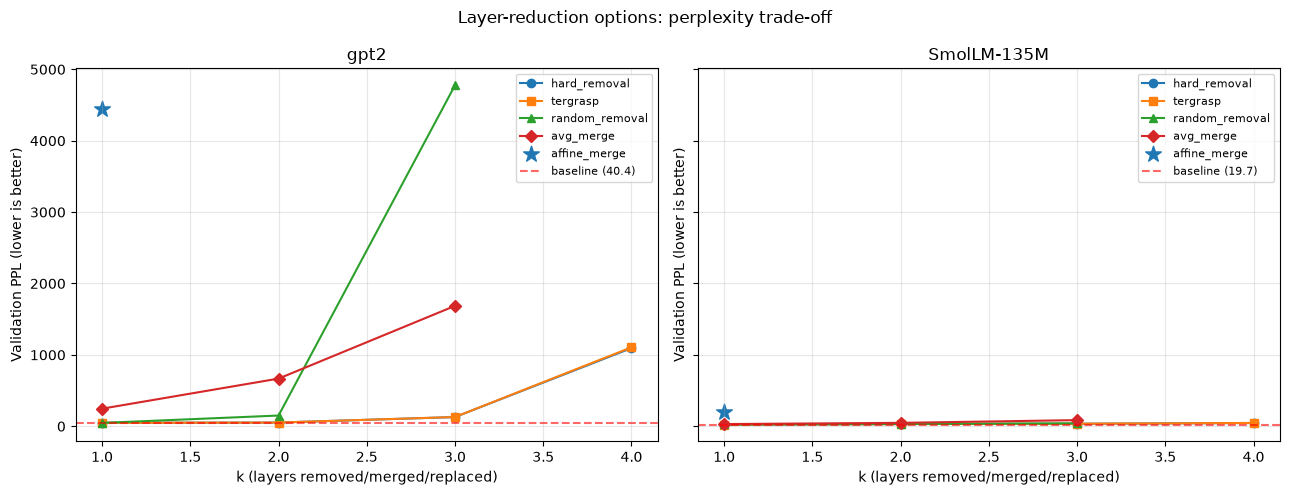

In [21]:
fig, axes = plt.subplots(1, len(MODEL_IDS), figsize=(13, 5), sharey=True)

for ax, mid in zip(axes, MODEL_IDS):
    for method, marker in [("hard_removal", "o"), ("tergrasp", "s"),
                           ("random_removal", "^")]:
        sub = results_df[(results_df["model"] == mid) & (results_df["method"] == method)]
        if len(sub):
            ax.plot(sub["k"], sub["ppl"], marker=marker, label=method)
    sub = results_df[(results_df["model"] == mid) & (results_df["method"] == "avg_merge")]
    if len(sub):
        ax.plot(sub["k"], sub["ppl"], marker="D", label="avg_merge")
    sub = results_df[(results_df["model"] == mid) & (results_df["method"] == "affine_merge")]
    if len(sub):
        ax.scatter([sub["k"].iloc[0]], [sub["ppl"].iloc[0]], marker="*", s=140,
                   label="affine_merge")
    base = baseline_df.loc[baseline_df["model"] == mid, "ppl"].iloc[0]
    ax.axhline(base, color="r", linestyle="--", alpha=0.6,
               label=f"baseline ({base:.1f})")
    ax.set_title(mid.split("/")[-1])
    ax.set_xlabel("k (layers removed/merged/replaced)")
    ax.set_ylabel("Validation PPL (lower is better)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Layer-reduction options: perplexity trade-off")
plt.tight_layout()
plt.show()


In [22]:
# Latency comparison: baseline vs hard k=2 vs TerGRASP k=2
latency_rows = []
for mid in MODEL_IDS:
    m0 = load_fresh_model(mid).to(device)
    bis = block_influence(m0, mid, train_text)
    free_model(m0)
    order = sorted(range(len(bis)), key=lambda i: bis[i])
    target = sorted(order[:2])

    m = load_fresh_model(mid).to(device)
    latency_rows.append({"model": mid, "config": "baseline",
                         "latency_ms": measure_latency(m, validation_text, mid)})
    free_model(m)

    m = hard_remove(mid, target).to(device)
    latency_rows.append({"model": mid, "config": "hard_removal k=2",
                         "latency_ms": measure_latency(m, validation_text, mid)})
    free_model(m)

    m = tergrasp_replace(mid, target).to(device)
    latency_rows.append({"model": mid, "config": "tergrasp k=2",
                         "latency_ms": measure_latency(m, validation_text, mid)})
    free_model(m)

latency_df = pd.DataFrame(latency_rows)
latency_df


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 12144.32it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 11874.15it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 10699.35it/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 11430.00it/s]

,model,config,latency_ms
0,openai-community/gpt2,baseline,61.966221
1,openai-community/gpt2,hard_removal k=2,53.694304
2,openai-community/gpt2,tergrasp k=2,54.005521
3,HuggingFaceTB/SmolLM-135M,baseline,786.550958
4,HuggingFaceTB/SmolLM-135M,hard_removal k=2,738.975717
5,HuggingFaceTB/SmolLM-135M,tergrasp k=2,733.540408


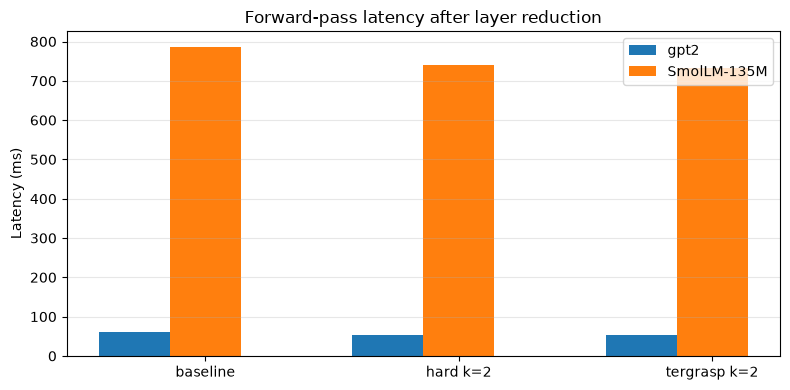

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
for i, mid in enumerate(MODEL_IDS):
    sub = latency_df[latency_df["model"] == mid]
    ax.bar([x + i * 0.28 for x in range(len(sub))], sub["latency_ms"],
           width=0.28, label=mid.split("/")[-1])
ax.set_xticks([x + 0.28 for x in range(3)])
ax.set_xticklabels(["baseline", "hard k=2", "tergrasp k=2"])
ax.set_ylabel("Latency (ms)")
ax.set_title("Forward-pass latency after layer reduction")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Conclusion

Look at the PPL-vs-k curves:

* Hard removal of a few lowest-influence layers often keeps PPL close to the
  baseline, while removing *random* layers degrades PPL much more - supporting
  the redundancy hypothesis.
* TerGRASP replacement retains the layer count of the computation graph but
  shrinks each replaced block to a 1.58-bit low-rank bridge, preserving the
  residual-stream shape; its PPL tracks hard removal closely.
* Weighted averaging / affine merging are cheap structural alternatives but
  usually drift PPL faster than angular-distance-guided hard removal.

Whichever keeps validation PPL within a small tolerance (e.g. <5% relative
increase) while reducing layers the most is the recommended configuration.
